---
title: "Non-stationary GEV — location-dependent tails"
---

# Annual temperature extremes over Spain — part 3: location-dependent tails

Parts [01](01_spain_extremes.ipynb) and [02](02_spain_multiplicative.ipynb)
kept the GEV **scale $\sigma$ and shape $\xi$ global** — every station shared
one tail. This notebook promotes both to **per-location spatial GPs**, so each
site gets its own $\sigma(s)$ and $\xi(s)$ on top of the location $\mu(s)$ and
warming rate $\beta(s)$ — **four latent spatial fields** in total.

Same package stack as before: `pyrox.gp` whitened `gp_sample` latents, an
`xtremax` GEV likelihood (now with per-station scale and shape), and NumPyro
SVI with an `AutoNormal` guide.

## Background — four-GP latent state

$$
\mu(s) \sim \mathcal{GP}(0, k_\mu), \quad
\tilde\beta(s) \sim \mathcal{GP}(0, k_\beta), \quad
\widetilde{\log\sigma}(s) \sim \mathcal{GP}(0, k_\sigma), \quad
\tilde\xi(s) \sim \mathcal{GP}(0, k_\xi),
$$

combined with scalar intercepts into the per-(s,t) GEV parameters

$$
\mu(s,t) = \mu_0 + \mu(s) + \bigl(\beta_0 + \tilde\beta(s)\bigr) d(t), \quad
\sigma(s) = \exp\!\bigl(\log\sigma_0 + \widetilde{\log\sigma}(s)\bigr), \quad
\xi(s) = \xi_0 + \tilde\xi(s),
$$

with $d(t) = \mathrm{GMST}(t) - \overline{\mathrm{GMST}}$ and
$y(s,t) \sim \mathrm{GEV}\bigl(\mu(s,t), \sigma(s), \xi(s)\bigr)$. $\log\sigma$
is modelled (not $\sigma$) to keep the scale positive. As before, every latent
field is **centered** so the four scalar intercepts own the global levels.

A caveat up front: $\xi$ is the hardest extreme-value parameter to estimate —
40 years per station carries little information about the tail shape, so the
$\xi(s)$ posterior is heavily shrunk toward $\xi_0$ by its GP prior. We recover
the *pattern* of $\xi(s)$ better than its amplitude.

## Setup

In [1]:
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Predictive, Trace_ELBO, autoguide
from numpyro.infer.initialization import init_to_value
from jaxtyping import Array, Float
from scipy.stats import genextreme

from pyrox.gp import GPPrior, Matern, gp_sample
from pyrox.gp._src.kernels import matern_kernel
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level

jax.config.update("jax_enable_x64", True)

/home/user/research_notebook/projects/gaussian_processes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data — stations, GMST, and the four truths

Stations and GMST are identical to nb 01–02.

In [2]:
SPAIN_BBOX = (-9.5, 3.5, 36.0, 43.8)


def _on_land(lon: Float[Array, " N"], lat: Float[Array, " N"]) -> Float[Array, " N"]:
    west_of_galicia = (lon < -8.8) & (lat > 42.3)
    below_africa = lat < 36.2
    east_mediterranean = (lon > 2.5) & (lat < 39.0)
    return ~(west_of_galicia | below_africa | east_mediterranean)


def _sample_stations(key: jr.PRNGKey, n_target: int) -> Float[Array, "n 2"]:
    candidates = jr.uniform(
        key, (n_target * 4, 2),
        minval=jnp.array([SPAIN_BBOX[0], SPAIN_BBOX[2]]),
        maxval=jnp.array([SPAIN_BBOX[1], SPAIN_BBOX[3]]),
    )
    return candidates[_on_land(candidates[:, 0], candidates[:, 1])][:n_target]


S = 40
T = 40
YEAR_0 = 1985
YEARS = jnp.arange(YEAR_0, YEAR_0 + T)

key = jr.PRNGKey(2024)
key, key_stations = jr.split(key)
stations = _sample_stations(key_stations, S)
lon_st, lat_st = stations[:, 0], stations[:, 1]


def synthetic_gmst(years: Float[Array, " T"], key: jr.PRNGKey) -> Float[Array, " T"]:
    t_norm = (years - years[0]) / jnp.maximum(years[-1] - years[0], 1)
    trend = 0.1 + 0.8 * t_norm
    white = 0.05 * jr.normal(key, (years.shape[0],))

    def step(prev, eps):
        cur = 0.6 * prev + eps
        return cur, cur

    _, red = jax.lax.scan(step, white[0], white[1:])
    return trend + jnp.concatenate([white[:1], red])


key, key_gmst = jr.split(key)
gmst = synthetic_gmst(YEARS, key_gmst)
d_vec = gmst - jnp.mean(gmst)

### Ground-truth latent fields

Four independent Matern-3/2 draws. $\xi$ gets a deliberately small variance
($0.003$) — realistic, since real tail-shape variation is modest.

In [3]:
def draw_from_gp(K: Float[Array, "N N"], key: jr.PRNGKey, jitter: float = 1e-4) -> Float[Array, " N"]:
    L = jnp.linalg.cholesky(K + jitter * jnp.eye(K.shape[0]))
    return L @ jr.normal(key, (K.shape[0],))


def _mk(var, ls):
    return matern_kernel(stations, stations, jnp.asarray(var), jnp.asarray(ls), nu=1.5)


TRUTH = {
    "mu0": 35.0, "beta0": 1.2, "logsig0": float(jnp.log(1.8)), "xi0": 0.12,
    "k_mu_var": 4.0, "k_mu_ls": 2.0, "k_beta_var": 0.25, "k_beta_ls": 3.0,
    "k_sig_var": 0.05, "k_sig_ls": 3.0, "k_xi_var": 0.003, "k_xi_ls": 3.0,
}

key, *subs = jr.split(key, 5)
mu_truth = draw_from_gp(_mk(TRUTH["k_mu_var"], TRUTH["k_mu_ls"]), subs[0])
beta_truth = TRUTH["beta0"] + draw_from_gp(_mk(TRUTH["k_beta_var"], TRUTH["k_beta_ls"]), subs[1])
logsig_truth = TRUTH["logsig0"] + draw_from_gp(_mk(TRUTH["k_sig_var"], TRUTH["k_sig_ls"]), subs[2])
xi_truth = TRUTH["xi0"] + draw_from_gp(_mk(TRUTH["k_xi_var"], TRUTH["k_xi_ls"]), subs[3])
sigma_truth = jnp.exp(logsig_truth)
print(f"mu*(s)    [{float(mu_truth.min()):.2f}, {float(mu_truth.max()):.2f}]")
print(f"beta*(s)  [{float(beta_truth.min()):.2f}, {float(beta_truth.max()):.2f}]")
print(f"sigma*(s) [{float(sigma_truth.min()):.2f}, {float(sigma_truth.max()):.2f}]")
print(f"xi*(s)    [{float(xi_truth.min()):.3f}, {float(xi_truth.max()):.3f}]")

f_truth = TRUTH["mu0"] + mu_truth[:, None] + beta_truth[:, None] * d_vec[None, :]  # (S, T)

mu*(s)    [-4.43, 3.74]
beta*(s)  [-0.02, 2.85]
sigma*(s) [1.53, 2.54]
xi*(s)    [-0.012, 0.223]


### GEV likelihood from `xtremax` (verified vs scipy) + per-station observations

Each station draws with its own $(\sigma^*(s), \xi^*(s))$, broadcast along time.

In [4]:
y_grid = jnp.linspace(-2.0, 25.0, 60)
ours = GEV(loc=3.0, scale=1.5, concentration=0.2).log_prob(y_grid)
theirs = genextreme.logpdf(np.asarray(y_grid), c=-0.2, loc=3.0, scale=1.5)
print(f"xtremax GEV vs scipy (ξ=0.2)  max|Δ| = {float(jnp.max(jnp.abs(ours - theirs))):.2e}")

key, key_obs = jr.split(key)
y_obs = GEV(loc=f_truth, scale=sigma_truth[:, None], concentration=xi_truth[:, None]).sample(key_obs)
Y_MEAN = float(jnp.mean(y_obs))
print(f"y_obs shape: {y_obs.shape}  range: [{float(y_obs.min()):.1f}, {float(y_obs.max()):.1f}] °C")

xtremax GEV vs scipy (ξ=0.2)  max|Δ| = 5.12e-13


y_obs shape: (40, 40)  range: [28.0, 56.1] °C


### Four truth maps

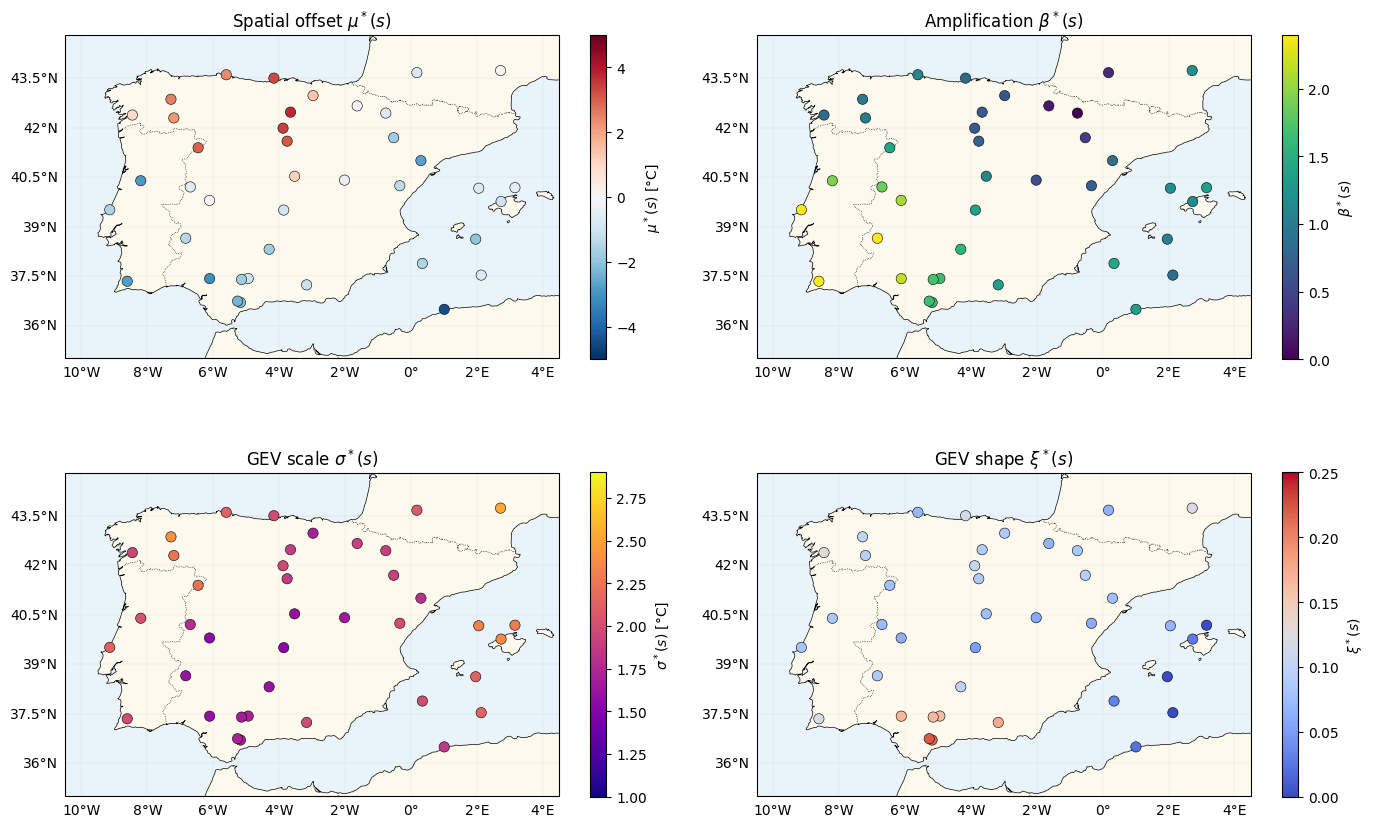

In [5]:
def plot_stations(ax, values, *, cmap: str, vlim: tuple, label: str) -> None:
    ax.set_extent([SPAIN_BBOX[0] - 1, SPAIN_BBOX[1] + 1, SPAIN_BBOX[2] - 1, SPAIN_BBOX[3] + 1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="#e8f3fa")
    ax.add_feature(cfeature.LAND, facecolor="#fdf9ec")
    sc = ax.scatter(
        np.asarray(lon_st), np.asarray(lat_st), c=np.asarray(values), cmap=cmap,
        vmin=vlim[0], vmax=vlim[1], s=55, edgecolors="k", linewidths=0.4,
        transform=ccrs.PlateCarree(), zorder=5,
    )
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(sc, ax=ax, shrink=0.75, label=label)


fig = plt.figure(figsize=(14, 9))
specs = [
    (1, mu_truth, "RdBu_r", (-5, 5), r"$\mu^*(s)$ [°C]", r"Spatial offset $\mu^*(s)$"),
    (2, beta_truth, "viridis", (0.0, 2.4), r"$\beta^*(s)$", r"Amplification $\beta^*(s)$"),
    (3, sigma_truth, "plasma", (1.0, 2.9), r"$\sigma^*(s)$ [°C]", r"GEV scale $\sigma^*(s)$"),
    (4, xi_truth, "coolwarm", (0.0, 0.25), r"$\xi^*(s)$", r"GEV shape $\xi^*(s)$"),
]
for idx, vals, cmap, vlim, label, title in specs:
    ax = fig.add_subplot(2, 2, idx, projection=ccrs.PlateCarree())
    plot_stations(ax, vals, cmap=cmap, vlim=vlim, label=label)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Model — four spatial GPs

Four `pyrox` GPs (distinct `pyrox_name`s), all centered; four scalar
intercepts; per-station $\sigma(s)$ and $\xi(s)$ fed straight into the
`xtremax` GEV likelihood.

In [6]:
def _kernel(name, var, ls):
    k = Matern(pyrox_name=name, nu=1.5)
    k.set_prior("variance", dist.LogNormal(jnp.log(var), 0.5))
    k.set_prior("lengthscale", dist.LogNormal(jnp.log(ls), 0.5))
    return k


def model(stations, d_vec, y=None):
    mu_s = gp_sample("mu_s", GPPrior(kernel=_kernel("k_mu", 2.0, 2.0), X=stations), whitened=True)
    beta_tilde = gp_sample("beta_tilde", GPPrior(kernel=_kernel("k_beta", 0.2, 3.0), X=stations), whitened=True)
    sig_r = gp_sample("sig_r", GPPrior(kernel=_kernel("k_sig", 0.05, 3.0), X=stations), whitened=True)
    xi_r = gp_sample("xi_r", GPPrior(kernel=_kernel("k_xi", 0.003, 3.0), X=stations), whitened=True)
    mu_s = mu_s - jnp.mean(mu_s)
    beta_tilde = beta_tilde - jnp.mean(beta_tilde)
    sig_r = sig_r - jnp.mean(sig_r)
    xi_r = xi_r - jnp.mean(xi_r)

    mu0 = numpyro.sample("mu0", dist.Normal(Y_MEAN, 5.0))
    beta0 = numpyro.sample("beta0", dist.Normal(1.0, 0.5))
    logsig0 = numpyro.sample("logsig0", dist.Normal(jnp.log(1.8), 0.3))
    xi0 = numpyro.sample("xi0", dist.Normal(0.1, 0.1))

    beta_s = beta0 + beta_tilde
    sigma_s = jnp.exp(logsig0 + sig_r)  # (S,)
    xi_s = xi0 + xi_r                   # (S,)
    loc = mu0 + mu_s[:, None] + beta_s[:, None] * d_vec[None, :]  # (S, T)

    numpyro.deterministic("mu_field", mu_s)
    numpyro.deterministic("beta_field", beta_s)
    numpyro.deterministic("sigma_field", sigma_s)
    numpyro.deterministic("xi_field", xi_s)
    numpyro.sample("y", GEV(loc=loc, scale=sigma_s[:, None], concentration=xi_s[:, None]), obs=y)

## Inference — SVI

With four per-station fields, a random whitened-latent start can push some
stations' $\sigma(s)/\xi(s)$ out of GEV support, so we additionally
**initialise the whitened GP bases (`*_u`) at zero** — at init every station
has $\sigma=1.8,\ \xi=0.1$ uniform, comfortably in-support.

In [7]:
zeros_S = jnp.zeros(S)
guide = autoguide.AutoNormal(
    model,
    init_loc_fn=init_to_value(values={
        "mu_s_u": zeros_S, "beta_tilde_u": zeros_S, "sig_r_u": zeros_S, "xi_r_u": zeros_S,
        "mu0": Y_MEAN, "beta0": 1.0, "logsig0": float(jnp.log(1.8)), "xi0": 0.1,
    }),
)
optimizer = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(3e-3))
)
svi = SVI(model, guide, optimizer, Trace_ELBO())

t0 = time.time()
svi_result = svi.run(jr.PRNGKey(0), 8000, stations, d_vec, y_obs, progress_bar=False)
losses = np.asarray(svi_result.losses)
post = Predictive(model, guide=guide, params=svi_result.params, num_samples=600)(
    jr.PRNGKey(3), stations, d_vec
)
lat = guide.sample_posterior(jr.PRNGKey(4), svi_result.params, sample_shape=(600,))
print(f"SVI finished in {time.time() - t0:.1f}s")


def _corr(a, b):
    return float(np.corrcoef(np.asarray(a), np.asarray(b))[0, 1])


sig_fit = post["sigma_field"].mean(0)
xi_fit = post["xi_field"].mean(0)
print(f"fitted μ₀ = {float(lat['mu0'].mean()):.2f} (35)   β₀ = {float(lat['beta0'].mean()):.2f} "
      f"(mean β* {float(beta_truth.mean()):.2f})")
print(f"fitted σ₀ = {float(jnp.exp(lat['logsig0'].mean())):.2f} (mean σ* {float(sigma_truth.mean()):.2f})   "
      f"ξ₀ = {float(lat['xi0'].mean()):.3f} (mean ξ* {float(xi_truth.mean()):.3f})")
print(f"truth-vs-fit corr:  μ={_corr(post['mu_field'].mean(0), mu_truth):.2f}  "
      f"β={_corr(post['beta_field'].mean(0), beta_truth):.2f}  "
      f"σ={_corr(sig_fit, sigma_truth):.2f}  ξ={_corr(xi_fit, xi_truth):.2f}")

SVI finished in 26.1s
fitted μ₀ = 34.65 (35)   β₀ = 1.36 (mean β* 1.23)
fitted σ₀ = 1.88 (mean σ* 1.94)   ξ₀ = 0.111 (mean ξ* 0.088)
truth-vs-fit corr:  μ=0.99  β=0.88  σ=0.87  ξ=0.57


### Loss curve

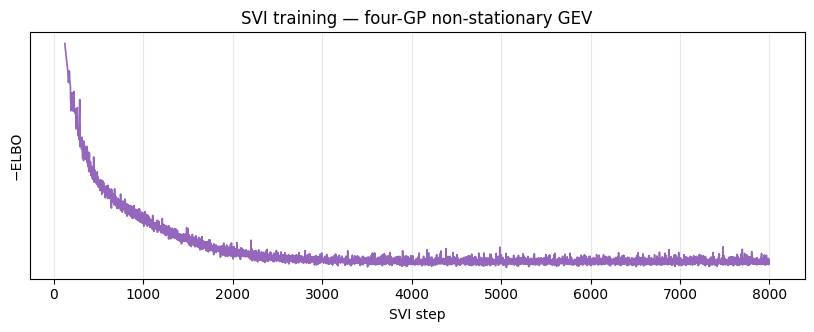

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.2))
finite = np.isfinite(losses)
ax.plot(np.arange(len(losses))[finite], losses[finite], "C4-", lw=1.2)
ax.set_xlabel("SVI step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=100.0)
ax.set_title("SVI training — four-GP non-stationary GEV")
ax.grid(alpha=0.3, which="both")
plt.show()

## Parameter recovery — four fields

Truth-vs-posterior scatter for each latent field. $\mu$ and $\sigma$ recover
well; $\beta$ is shrunk modestly; $\xi$ is the hardest — its posterior is
pulled strongly toward $\xi_0$ by the GP prior, so the cloud is compressed
along the vertical axis (low amplitude, but the pattern correlation is
positive).

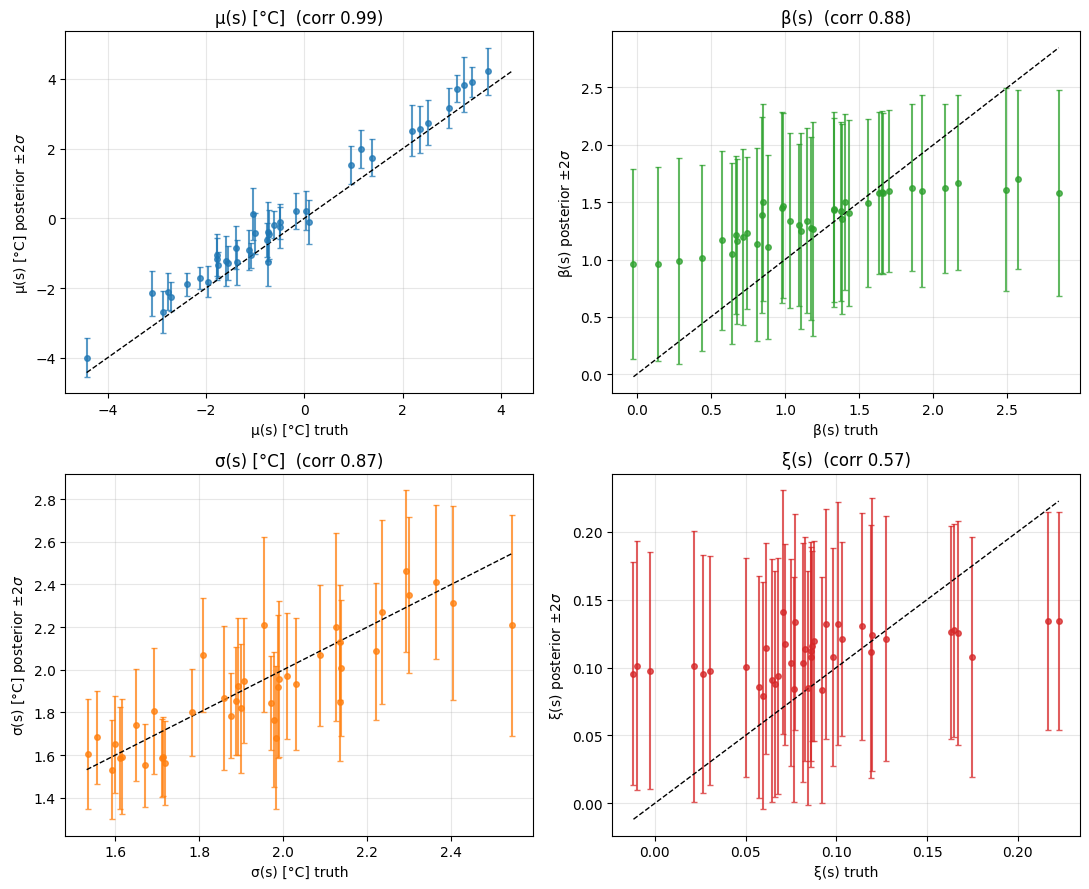

In [9]:
fields = [
    ("μ(s) [°C]", post["mu_field"].mean(0), post["mu_field"].std(0), mu_truth, "C0"),
    ("β(s)", post["beta_field"].mean(0), post["beta_field"].std(0), beta_truth, "C2"),
    ("σ(s) [°C]", sig_fit, post["sigma_field"].std(0), sigma_truth, "C1"),
    ("ξ(s)", xi_fit, post["xi_field"].std(0), xi_truth, "C3"),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, fit, sd, truth, c) in zip(axes.flat, fields, strict=True):
    ax.errorbar(np.asarray(truth), np.asarray(fit), yerr=2 * np.asarray(sd),
                fmt="o", color=c, ms=4, alpha=0.75, capsize=2)
    lo = float(min(np.min(truth), np.min(fit)))
    hi = float(max(np.max(truth), np.max(fit)))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel(f"{name} truth")
    ax.set_ylabel(rf"{name} posterior $\pm 2\sigma$")
    ax.set_title(f"{name}  (corr {_corr(fit, truth):.2f})")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### The two spatial signatures — $\hat\sigma(s)$ and $\hat\xi(s)$

The new ingredients of this notebook: maps of the recovered GEV scale and
shape fields, side by side with their truths.

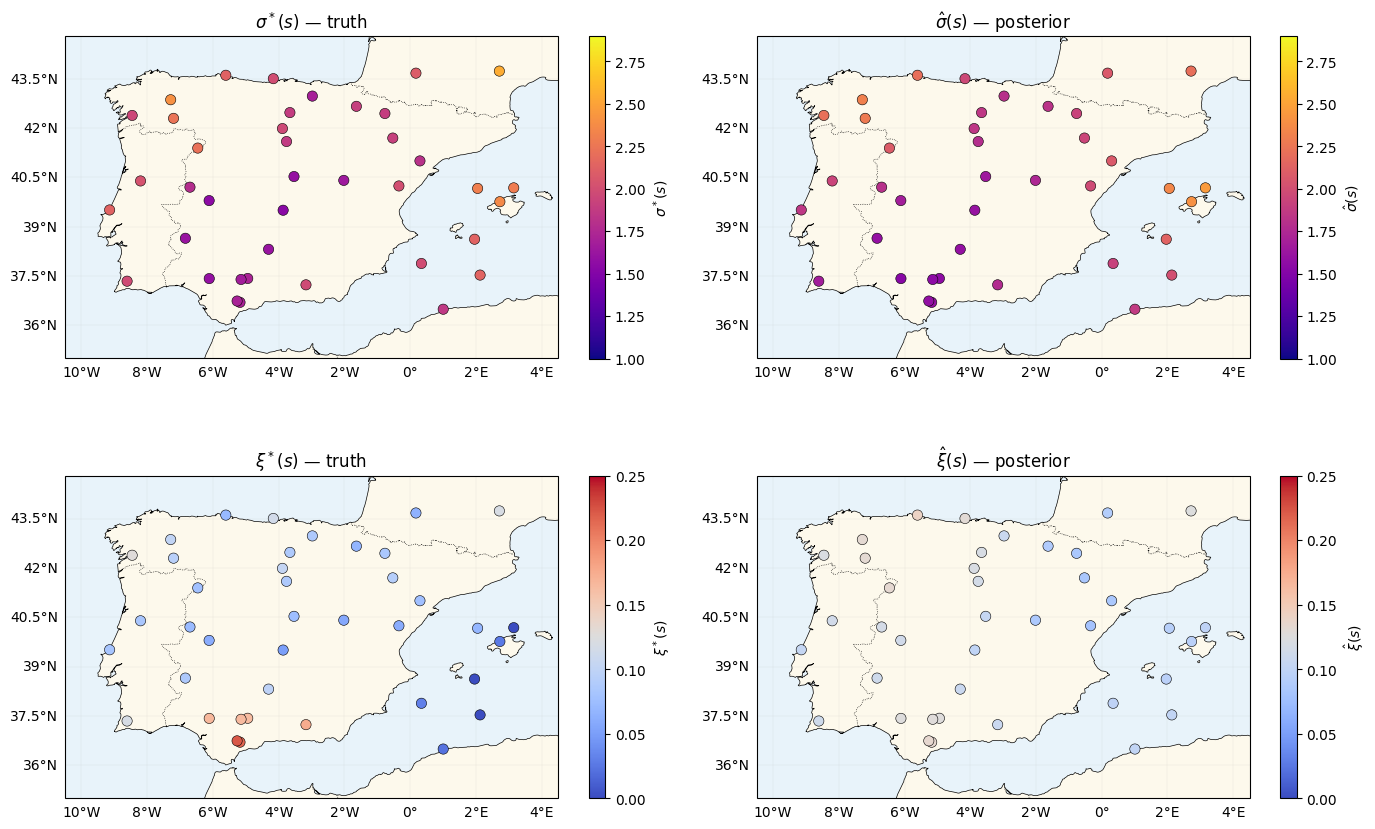

In [10]:
fig = plt.figure(figsize=(14, 9))
sig_specs = [
    (1, sigma_truth, "plasma", (1.0, 2.9), r"$\sigma^*(s)$ — truth"),
    (2, sig_fit, "plasma", (1.0, 2.9), r"$\hat\sigma(s)$ — posterior"),
    (3, xi_truth, "coolwarm", (0.0, 0.25), r"$\xi^*(s)$ — truth"),
    (4, xi_fit, "coolwarm", (0.0, 0.25), r"$\hat\xi(s)$ — posterior"),
]
for idx, vals, cmap, vlim, title in sig_specs:
    ax = fig.add_subplot(2, 2, idx, projection=ccrs.PlateCarree())
    plot_stations(ax, vals, cmap=cmap, vlim=vlim, label=title.split(" ")[0])
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Return-level maps with location-dependent tails

Now both the location $\hat\tau(s, t^*)$ **and** the tail $(\hat\sigma(s),
\hat\xi(s))$ vary in space, so the return-level maps carry spatial structure
from all four fields. We use `xtremax.gev_return_level` with per-station
scale and shape.

100-yr return shift 2024→2050: mean 0.75 °C


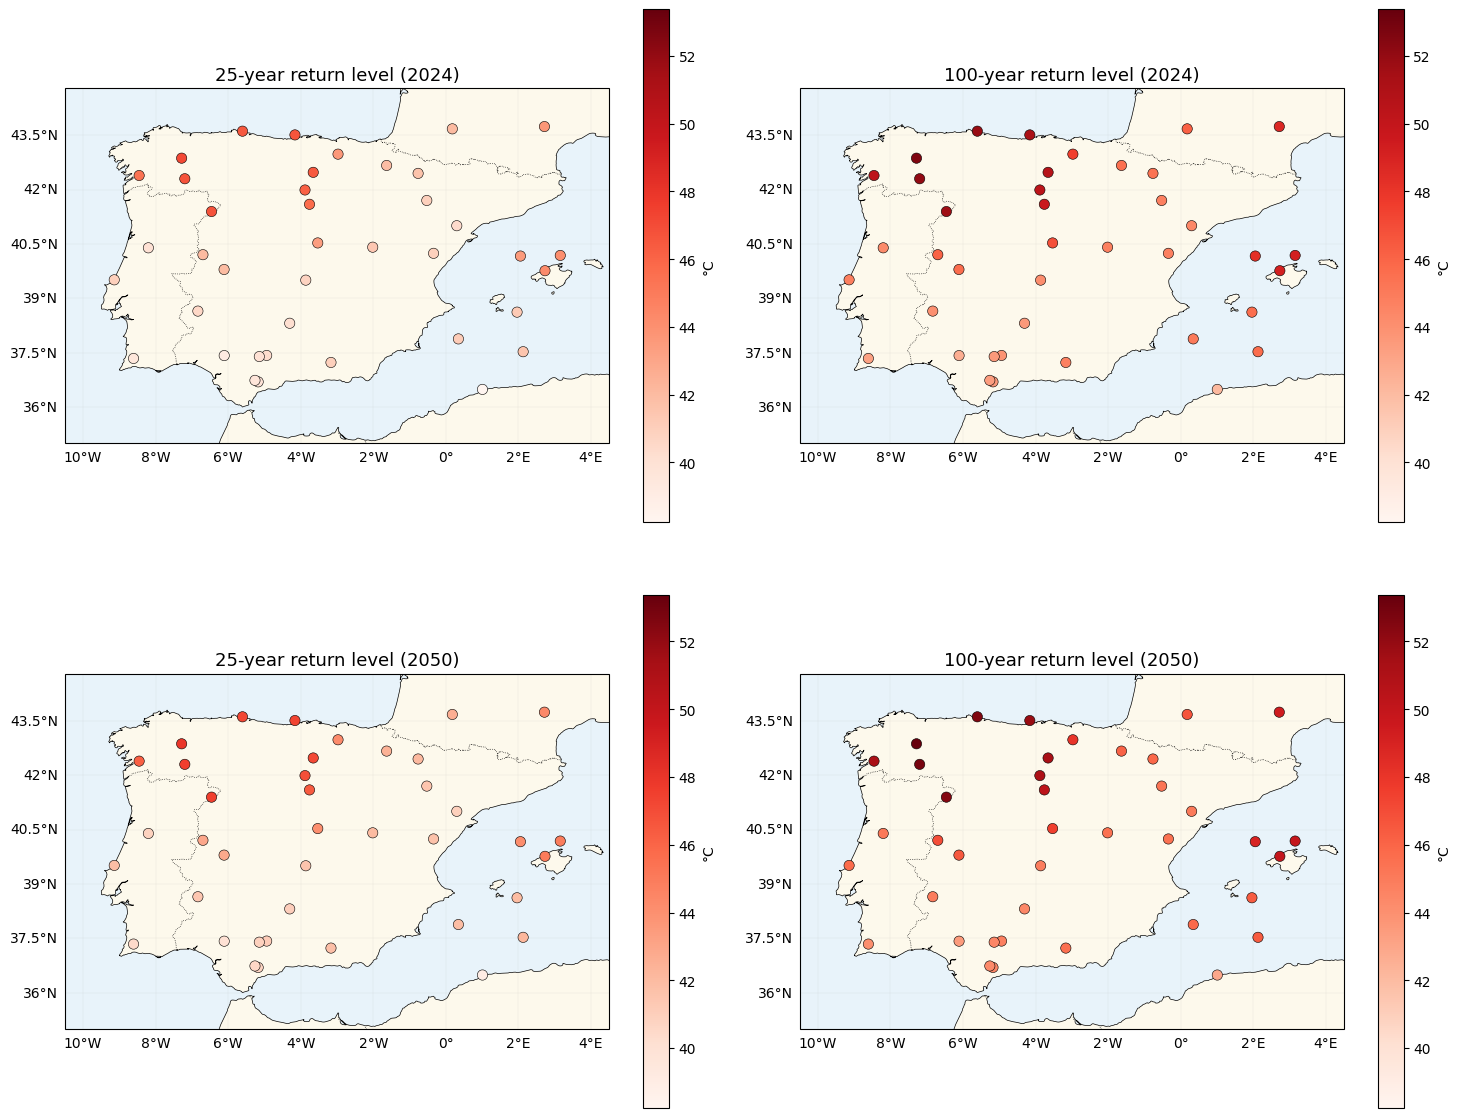

In [11]:
mu0_p = float(lat["mu0"].mean())
mu_field_mean = post["mu_field"].mean(0)
beta_field_mean = post["beta_field"].mean(0)

gmst_2024 = gmst[-1]
gmst_2050 = gmst[-1] + (gmst[-1] - gmst[0]) / (T - 1) * (2050 - (YEAR_0 + T - 1))
tau_2024 = mu0_p + mu_field_mean + beta_field_mean * (gmst_2024 - jnp.mean(gmst))
tau_2050 = mu0_p + mu_field_mean + beta_field_mean * (gmst_2050 - jnp.mean(gmst))

z25_2024 = gev_return_level(25.0, tau_2024, sig_fit, xi_fit)
z100_2024 = gev_return_level(100.0, tau_2024, sig_fit, xi_fit)
z25_2050 = gev_return_level(25.0, tau_2050, sig_fit, xi_fit)
z100_2050 = gev_return_level(100.0, tau_2050, sig_fit, xi_fit)

stacked = jnp.stack([z25_2024, z100_2024, z25_2050, z100_2050])
vmin, vmax = float(jnp.min(stacked)), float(jnp.max(stacked))
print(f"100-yr return shift 2024→2050: mean {float(jnp.mean(z100_2050 - z100_2024)):.2f} °C")

fig, axes = plt.subplots(2, 2, figsize=(15, 13), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, values, title in zip(
    axes.flat, [z25_2024, z100_2024, z25_2050, z100_2050],
    ["25-year return level (2024)", "100-year return level (2024)",
     "25-year return level (2050)", "100-year return level (2050)"],
    strict=True,
):
    plot_stations(ax, values, cmap="Reds", vlim=(vmin, vmax), label="°C")
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.show()

### Where the tail matters — 100yr − 25yr gap

The gap $z_{100} - z_{25}$ is governed almost entirely by the local tail
$(\hat\sigma(s), \hat\xi(s))$: heavier-tailed stations (larger $\sigma$ or
$\xi$) show a bigger jump from the 25- to the 100-year level. Under nb 01–02
(global $\sigma, \xi$) this map would be nearly flat.

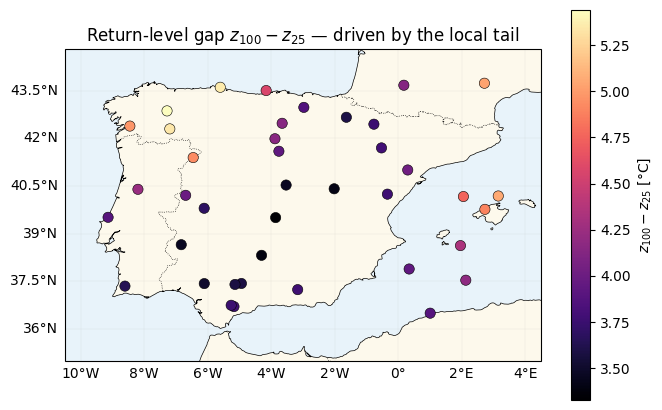

In [12]:
gap = z100_2024 - z25_2024
fig, ax = plt.subplots(figsize=(6.8, 5.5), subplot_kw={"projection": ccrs.PlateCarree()})
plot_stations(ax, gap, cmap="magma", vlim=(float(gap.min()), float(gap.max())),
              label=r"$z_{100} - z_{25}$ [°C]")
ax.set_title(r"Return-level gap $z_{100} - z_{25}$ — driven by the local tail")
plt.tight_layout()
plt.show()

## Contrast with nb 02

| Aspect | nb 02 (multiplicative) | nb 03 (non-stationary tail) |
|---|---|---|
| Latent fields | $\mu(s)$, $\tilde\beta(s)$ | $\mu(s)$, $\tilde\beta(s)$, $\widetilde{\log\sigma}(s)$, $\tilde\xi(s)$ |
| GEV scale $\sigma$ | global | $\sigma(s)$ spatial GP |
| GEV shape $\xi$ | global | $\xi(s)$ spatial GP |
| $z_{100}-z_{25}$ map | ~flat | spatially varying |

The cost of going from two GPs to four is two more `gp_sample` calls and two
more scalar intercepts — the inference recipe is otherwise identical.

## Summary

- Four `pyrox` spatial GPs feed an `xtremax` GEV likelihood with **per-station
  scale and shape**; NumPyro SVI infers all four fields jointly.
- Centering every field + initialising the whitened GP bases at zero keeps the
  richer model identifiable and in-support during early SVI.
- $\mu$ and $\sigma$ recover well; $\beta$ is modestly shrunk; $\xi$ is the
  hardest (tiny signal, strong prior shrinkage) — an honest reflection of how
  little 40 years of maxima say about the tail shape.
- The return-level **gap** $z_{100}-z_{25}$ now carries spatial structure from
  the local tail — impossible under the global-tail models of nb 01–02.

### Follow-ups

- **Cross-station dependence** — a Gaussian copula on the residuals (nb 04).
- **Temporal non-stationarity in $\sigma, \xi$** — let the tail itself drift
  with GMST, not just space.